In [19]:
import pandas as pd
import os
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

# Constants

In [2]:
str_project = os.getcwd().split('\\')[4]
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[5]
print(f'Task: {str_task}')
str_subtask = os.getcwd().split('\\')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

Project: 06_ml_in_python
Task: 01_home_credit_model
Subtask: 04_model_building


In [3]:
os.getcwd()

'M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\01_home_credit_model\\04_model_building'

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

# Pull in all datasets

In [5]:
df_train = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\01_home_credit_model\\03_preprocessing\\output\\df_train.csv')
df_train

,rownum,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,396902,0,Cash loans,F,Y,Y,0,121500,835380,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
1,1,112096,0,Cash loans,F,N,Y,0,202500,516069,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,6.0
2,2,285821,1,Cash loans,M,Y,Y,1,180000,284400,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
3,3,376901,0,Cash loans,F,N,Y,0,90000,265536,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
4,4,325138,0,Cash loans,F,Y,Y,0,94500,755190,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87495,87495,347233,1,Cash loans,M,Y,Y,1,202500,436500,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,3.0
87496,87496,415155,0,Cash loans,F,N,Y,1,90000,325908,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
87497,87497,452814,0,Cash loans,M,Y,Y,1,270000,971280,...,0,0,0,0,0.0,0.0,2.0,0.0,0.0,2.0
87498,87498,346541,0,Cash loans,F,N,Y,0,135000,640080,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
df_test = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\01_home_credit_model\\03_preprocessing\\output\\df_test.csv')
df_test

,rownum,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,106250,349548,1,Cash loans,F,Y,Y,1,112500,545040,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,3.0
1,106251,115330,1,Cash loans,F,N,Y,1,112500,553806,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,106252,156518,0,Cash loans,M,N,Y,0,126000,269982,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0
3,106253,391420,0,Cash loans,F,Y,Y,0,135000,526491,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,106254,351610,0,Cash loans,F,N,Y,2,126000,331632,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18745,124995,217133,0,Revolving loans,M,Y,Y,0,54000,157500,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
18746,124996,169482,0,Cash loans,F,N,N,0,180000,661500,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,2.0
18747,124997,333982,0,Cash loans,F,N,Y,0,90000,239850,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
18748,124998,249620,0,Revolving loans,M,N,Y,0,76500,180000,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,0.0


In [7]:
df_valid = pd.read_csv('M:\\Risk Management\\Bridger Hyde\\20240521_bridger_internship\\06_ml_in_python\\01_home_credit_model\\03_preprocessing\\output\\df_valid.csv')
df_valid

,rownum,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,87500,356241,1,Cash loans,M,N,Y,0,220500,816660,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
1,87501,443823,0,Cash loans,F,N,N,0,220500,1535553,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,87502,401657,0,Cash loans,M,Y,Y,1,315000,857169,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
3,87503,145013,0,Cash loans,F,Y,Y,1,112500,697500,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,87504,231633,0,Cash loans,M,Y,N,1,225000,805536,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18745,106245,140745,0,Cash loans,F,N,N,1,157500,942300,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
18746,106246,155170,1,Cash loans,F,N,Y,2,81000,418500,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
18747,106247,139134,0,Cash loans,F,N,Y,0,112500,1139846,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
18748,106248,188087,0,Cash loans,F,Y,Y,0,166500,472500,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# 1st Model Test

In [8]:
X_train = df_train.drop(columns=['TARGET'])
y_train = df_train['TARGET']

X_valid = df_valid.drop(columns=['TARGET'])
y_valid = df_valid['TARGET']

X_test = df_test.drop(columns=['TARGET'])
y_test = df_test['TARGET']

In [9]:
model = CatBoostClassifier(
    iterations = 1500,
    learning_rate=0.02,
    depth=8,
    verbose=50
)

In [8]:
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [12]:
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_columns)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_columns)

In [13]:
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6729234	test: 0.6728810	best: 0.6728810 (0)	total: 272ms	remaining: 6m 47s
50:	learn: 0.2995641	test: 0.2990631	best: 0.2990631 (50)	total: 14.5s	remaining: 6m 51s
100:	learn: 0.2602752	test: 0.2604773	best: 0.2604773 (100)	total: 28.5s	remaining: 6m 34s
150:	learn: 0.2513477	test: 0.2532334	best: 0.2532334 (150)	total: 41.9s	remaining: 6m 14s
200:	learn: 0.2471336	test: 0.2506220	best: 0.2506220 (200)	total: 54.9s	remaining: 5m 54s
250:	learn: 0.2441682	test: 0.2492737	best: 0.2492737 (250)	total: 1m 7s	remaining: 5m 36s
300:	learn: 0.2417743	test: 0.2485812	best: 0.2485774 (299)	total: 1m 20s	remaining: 5m 20s
350:	learn: 0.2398584	test: 0.2481638	best: 0.2481610 (349)	total: 1m 33s	remaining: 5m 5s
400:	learn: 0.2380350	test: 0.2479555	best: 0.2479555 (400)	total: 1m 45s	remaining: 4m 50s
450:	learn: 0.2363076	test: 0.2477391	best: 0.2477391 (450)	total: 1m 59s	remaining: 4m 37s
500:	learn: 0.2347189	test: 0.2475530	best: 0.2475529 (499)	total: 2m 12s	remaining: 4m 23s
5

In [14]:
y_valid_pred = model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy: ", test_accuracy)

Validation Accuracy:  0.9199466666666667
Test Accuracy:  0.9195733333333334


In [15]:
feature_importances = model.get_feature_importance()
feature_names = X_train.columns

feature_importance_pairs = list(zip(feature_names, feature_importances))
sorted_feature_importance_pairs = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

for feature, importance in sorted_feature_importance_pairs:
    print(f'{feature}: {importance}')

EXT_SOURCE_3: 12.583259809821818
EXT_SOURCE_2: 11.425432205890912
EXT_SOURCE_1: 6.09918515476201
DAYS_BIRTH: 4.171291966526367
AMT_GOODS_PRICE: 3.809131169402788
AMT_CREDIT: 3.754783427246804
CODE_GENDER: 2.763813063656411
DAYS_LAST_PHONE_CHANGE: 2.745026287827791
AMT_ANNUITY: 2.716829370226069
NAME_EDUCATION_TYPE: 2.5802463060622736
ORGANIZATION_TYPE: 2.5446174049552237
DAYS_ID_PUBLISH: 2.4784844288231915
DAYS_EMPLOYED: 2.291192545927628
DAYS_REGISTRATION: 2.0796549612713853
rownum: 1.5926634560840978
NAME_INCOME_TYPE: 1.5657652890270934
AMT_INCOME_TOTAL: 1.5118325860587394
FLAG_OWN_CAR: 1.4432617520979294
SK_ID_CURR: 1.376731261380298
NAME_FAMILY_STATUS: 1.3311325375482372
OCCUPATION_TYPE: 1.3069356611194132
REGION_POPULATION_RELATIVE: 1.291560947180951
FLAG_DOCUMENT_3: 1.1094636512611382
AMT_REQ_CREDIT_BUREAU_YEAR: 1.0760830843877693
DEF_30_CNT_SOCIAL_CIRCLE: 1.0488857858372744
HOUR_APPR_PROCESS_START: 1.0176813691317825
FLAG_WORK_PHONE: 0.8807455861674779
REGION_RATING_CLIENT_W_CIT

# Remove Some of the undeeded columns 

## Model 2

In [16]:
X_train = df_train.drop(columns=['TARGET','rownum','SK_ID_CURR'])
y_train = df_train['TARGET']

X_valid = df_valid.drop(columns=['TARGET','rownum','SK_ID_CURR'])
y_valid = df_valid['TARGET']

X_test = df_test.drop(columns=['TARGET','rownum','SK_ID_CURR'])
y_test = df_test['TARGET']

In [17]:
# adjusting iterations based on previous score
model = CatBoostClassifier(
    iterations = 850,
    learning_rate=0.02,
    depth=8,
    verbose=50
)

In [18]:
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_columns)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_columns)

In [19]:
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6722205	test: 0.6721806	best: 0.6721806 (0)	total: 243ms	remaining: 3m 26s
50:	learn: 0.2975143	test: 0.2970210	best: 0.2970210 (50)	total: 13.4s	remaining: 3m 30s
100:	learn: 0.2596416	test: 0.2599759	best: 0.2599759 (100)	total: 24s	remaining: 2m 57s
150:	learn: 0.2507620	test: 0.2527962	best: 0.2527962 (150)	total: 36.5s	remaining: 2m 48s
200:	learn: 0.2466342	test: 0.2503498	best: 0.2503498 (200)	total: 50.2s	remaining: 2m 42s
250:	learn: 0.2436371	test: 0.2489926	best: 0.2489926 (250)	total: 1m 3s	remaining: 2m 31s
300:	learn: 0.2415000	test: 0.2483251	best: 0.2483147 (299)	total: 1m 15s	remaining: 2m 17s
350:	learn: 0.2396888	test: 0.2478065	best: 0.2478065 (350)	total: 1m 27s	remaining: 2m 4s
400:	learn: 0.2379202	test: 0.2475272	best: 0.2475272 (400)	total: 1m 39s	remaining: 1m 51s
450:	learn: 0.2362104	test: 0.2473537	best: 0.2473537 (450)	total: 1m 51s	remaining: 1m 38s
500:	learn: 0.2344588	test: 0.2471409	best: 0.2471382 (498)	total: 2m 3s	remaining: 1m 25s
550:

In [20]:
y_valid_pred = model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy: ", test_accuracy)

Validation Accuracy:  0.92016
Test Accuracy:  0.91936


In [21]:
feature_importances = model.get_feature_importance()
feature_names = X_train.columns

feature_importance_pairs = list(zip(feature_names, feature_importances))
sorted_feature_importance_pairs = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

for feature, importance in sorted_feature_importance_pairs:
    print(f'{feature}: {importance}')

EXT_SOURCE_3: 13.026539599336253
EXT_SOURCE_2: 11.47538121689546
EXT_SOURCE_1: 6.254244547288362
DAYS_BIRTH: 4.118241379546655
AMT_GOODS_PRICE: 4.117806777144479
AMT_CREDIT: 3.8145986227351556
CODE_GENDER: 3.0067544224701837
DAYS_EMPLOYED: 2.9607368414271904
DAYS_LAST_PHONE_CHANGE: 2.931194572870713
AMT_ANNUITY: 2.8780856461931887
ORGANIZATION_TYPE: 2.624393744137375
NAME_EDUCATION_TYPE: 2.5195107086116595
DAYS_ID_PUBLISH: 2.4877778581045598
DAYS_REGISTRATION: 1.9138481852666782
NAME_INCOME_TYPE: 1.7233387393666362
AMT_INCOME_TOTAL: 1.6131173783924688
OCCUPATION_TYPE: 1.5690946958452228
FLAG_OWN_CAR: 1.5003406298751423
REGION_POPULATION_RELATIVE: 1.4224475548076785
NAME_FAMILY_STATUS: 1.2981405678636202
FLAG_DOCUMENT_3: 1.1669825642358094
HOUR_APPR_PROCESS_START: 1.0857335409952842
DEF_30_CNT_SOCIAL_CIRCLE: 1.048526511232618
FLAG_WORK_PHONE: 0.8504918923495861
AMT_REQ_CREDIT_BUREAU_YEAR: 0.8055232259823176
OBS_60_CNT_SOCIAL_CIRCLE: 0.7686893691754668
REGION_RATING_CLIENT_W_CITY: 0.7358

# Model 3 Removing all uneeded columns

In [22]:
X_train = df_train.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_12','FLAG_DOCUMENT_10','FLAG_MOBIL','FLAG_DOCUMENT_4','FLAG_DOCUMENT_2','FLAG_DOCUMENT_7','FLAG_DOCUMENT_17','FLAG_DOCUMENT_15','FLAG_CONT_MOBILE','FLAG_DOCUMENT_20','FLAG_DOCUMENT_19','FLAG_DOCUMENT_11','FLAG_DOCUMENT_21'])
y_train = df_train['TARGET']

X_valid = df_valid.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_12','FLAG_DOCUMENT_10','FLAG_MOBIL','FLAG_DOCUMENT_4','FLAG_DOCUMENT_2','FLAG_DOCUMENT_7','FLAG_DOCUMENT_17','FLAG_DOCUMENT_15','FLAG_CONT_MOBILE','FLAG_DOCUMENT_20','FLAG_DOCUMENT_19','FLAG_DOCUMENT_11','FLAG_DOCUMENT_21'])
y_valid = df_valid['TARGET']

X_test = df_test.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_12','FLAG_DOCUMENT_10','FLAG_MOBIL','FLAG_DOCUMENT_4','FLAG_DOCUMENT_2','FLAG_DOCUMENT_7','FLAG_DOCUMENT_17','FLAG_DOCUMENT_15','FLAG_CONT_MOBILE','FLAG_DOCUMENT_20','FLAG_DOCUMENT_19','FLAG_DOCUMENT_11','FLAG_DOCUMENT_21'])
y_test = df_test['TARGET']

In [23]:
#change verbose to see effect
model = CatBoostClassifier(
    iterations = 850,
    learning_rate=0.02,
    depth=8,
    verbose=35
)

In [24]:
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_columns)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_columns)

In [25]:
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6729761	test: 0.6729444	best: 0.6729444 (0)	total: 246ms	remaining: 3m 29s
35:	learn: 0.3370459	test: 0.3363685	best: 0.3363685 (35)	total: 9.44s	remaining: 3m 33s
70:	learn: 0.2749162	test: 0.2745567	best: 0.2745567 (70)	total: 17.2s	remaining: 3m 8s
105:	learn: 0.2585029	test: 0.2589450	best: 0.2589450 (105)	total: 26s	remaining: 3m 2s
140:	learn: 0.2520408	test: 0.2536763	best: 0.2536763 (140)	total: 34.6s	remaining: 2m 54s
175:	learn: 0.2483200	test: 0.2513085	best: 0.2513085 (175)	total: 44.3s	remaining: 2m 49s
210:	learn: 0.2460081	test: 0.2500965	best: 0.2500965 (210)	total: 53.9s	remaining: 2m 43s
245:	learn: 0.2439570	test: 0.2492475	best: 0.2492475 (245)	total: 1m 5s	remaining: 2m 41s
280:	learn: 0.2420985	test: 0.2486522	best: 0.2486522 (280)	total: 1m 15s	remaining: 2m 32s
315:	learn: 0.2405397	test: 0.2482101	best: 0.2482101 (315)	total: 1m 23s	remaining: 2m 21s
350:	learn: 0.2393254	test: 0.2478991	best: 0.2478991 (350)	total: 1m 31s	remaining: 2m 10s
385:	lea

In [26]:
y_valid_pred = model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy: ", test_accuracy)

Validation Accuracy:  0.9202666666666667
Test Accuracy:  0.9194666666666667


In [27]:
feature_importances = model.get_feature_importance()
feature_names = X_train.columns

feature_importance_pairs = list(zip(feature_names, feature_importances))
sorted_feature_importance_pairs = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

for feature, importance in sorted_feature_importance_pairs:
    print(f'{feature}: {importance}')

EXT_SOURCE_3: 13.12510283083879
EXT_SOURCE_2: 11.979005408460342
EXT_SOURCE_1: 5.930943720243598
DAYS_BIRTH: 4.001088750548606
AMT_CREDIT: 3.8618008099251258
AMT_GOODS_PRICE: 3.848334434145526
CODE_GENDER: 3.058699655070571
AMT_ANNUITY: 2.9367916526100295
NAME_EDUCATION_TYPE: 2.841957476066498
ORGANIZATION_TYPE: 2.7762967128129326
DAYS_LAST_PHONE_CHANGE: 2.6805683984568893
DAYS_EMPLOYED: 2.5031867958190723
DAYS_ID_PUBLISH: 2.4388777628350153
DAYS_REGISTRATION: 2.037217807237007
NAME_INCOME_TYPE: 1.692829460460379
OCCUPATION_TYPE: 1.6311786220262143
REGION_POPULATION_RELATIVE: 1.5482491346780056
FLAG_OWN_CAR: 1.5354706266717124
AMT_INCOME_TOTAL: 1.4919569713320098
NAME_FAMILY_STATUS: 1.3599763623835701
FLAG_DOCUMENT_3: 1.1616253878832556
HOUR_APPR_PROCESS_START: 1.1516546069782203
DEF_30_CNT_SOCIAL_CIRCLE: 0.9949619429841765
AMT_REQ_CREDIT_BUREAU_YEAR: 0.8576074452847623
FLAG_WORK_PHONE: 0.8448487973839215
REGION_RATING_CLIENT_W_CITY: 0.7524332740100488
WEEKDAY_APPR_PROCESS_START: 0.719

# Model 4 Final Model

In [9]:
X_train = df_train.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_12','FLAG_DOCUMENT_10','FLAG_DOCUMENT_17','FLAG_DOCUMENT_15','FLAG_CONT_MOBILE','FLAG_DOCUMENT_20','FLAG_DOCUMENT_19','FLAG_DOCUMENT_11','FLAG_DOCUMENT_21'])
y_train = df_train['TARGET']

X_valid = df_valid.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_12','FLAG_DOCUMENT_10','FLAG_DOCUMENT_17','FLAG_DOCUMENT_15','FLAG_CONT_MOBILE','FLAG_DOCUMENT_20','FLAG_DOCUMENT_19','FLAG_DOCUMENT_11','FLAG_DOCUMENT_21'])
y_valid = df_valid['TARGET']

X_test = df_test.drop(columns=['TARGET','rownum','SK_ID_CURR','FLAG_DOCUMENT_12','FLAG_DOCUMENT_10','FLAG_DOCUMENT_17','FLAG_DOCUMENT_15','FLAG_CONT_MOBILE','FLAG_DOCUMENT_20','FLAG_DOCUMENT_19','FLAG_DOCUMENT_11','FLAG_DOCUMENT_21'])
y_test = df_test['TARGET']

In [10]:
#changing depth to see effect
model = CatBoostClassifier(
    iterations = 830,
    learning_rate=0.02,
    depth=6,
    verbose=35
)

In [11]:
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_columns)
valid_pool = Pool(data=X_valid, label=y_valid, cat_features=categorical_columns)

In [12]:
model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	learn: 0.6730472	test: 0.6730238	best: 0.6730238 (0)	total: 259ms	remaining: 3m 35s
35:	learn: 0.3394621	test: 0.3387029	best: 0.3387029 (35)	total: 6.39s	remaining: 2m 20s
70:	learn: 0.2771573	test: 0.2765174	best: 0.2765174 (70)	total: 12.5s	remaining: 2m 13s
105:	learn: 0.2617220	test: 0.2614169	best: 0.2614169 (105)	total: 18.8s	remaining: 2m 8s
140:	learn: 0.2557667	test: 0.2557782	best: 0.2557782 (140)	total: 25.1s	remaining: 2m 2s
175:	learn: 0.2527464	test: 0.2530810	best: 0.2530810 (175)	total: 32.3s	remaining: 2m
210:	learn: 0.2509159	test: 0.2516687	best: 0.2516687 (210)	total: 38.7s	remaining: 1m 53s
245:	learn: 0.2495575	test: 0.2507088	best: 0.2507088 (245)	total: 45s	remaining: 1m 46s
280:	learn: 0.2484522	test: 0.2500754	best: 0.2500754 (280)	total: 51.7s	remaining: 1m 40s
315:	learn: 0.2475292	test: 0.2495499	best: 0.2495499 (315)	total: 58.6s	remaining: 1m 35s
350:	learn: 0.2468419	test: 0.2492508	best: 0.2492508 (350)	total: 1m 6s	remaining: 1m 30s
385:	learn: 0.2

In [13]:
y_valid_pred = model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print("Validation Accuracy: ", valid_accuracy)

y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy: ", test_accuracy)

Validation Accuracy:  0.9204266666666666
Test Accuracy:  0.91984


In [1]:
feature_importances = model.get_feature_importance()
feature_names = X_train.columns

feature_importance_pairs = list(zip(feature_names, feature_importances))
sorted_feature_importance_pairs = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

for feature, importance in sorted_feature_importance_pairs:
    print(f'{feature}: {importance}')

NameError: name 'model' is not defined

In [15]:
y_score = model.predict_proba(X_test)[:, 1]
print(y_score)

[0.33615465 0.09800129 0.1467661  ... 0.04460641 0.03609891 0.20402797]


# Create ROC curve

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

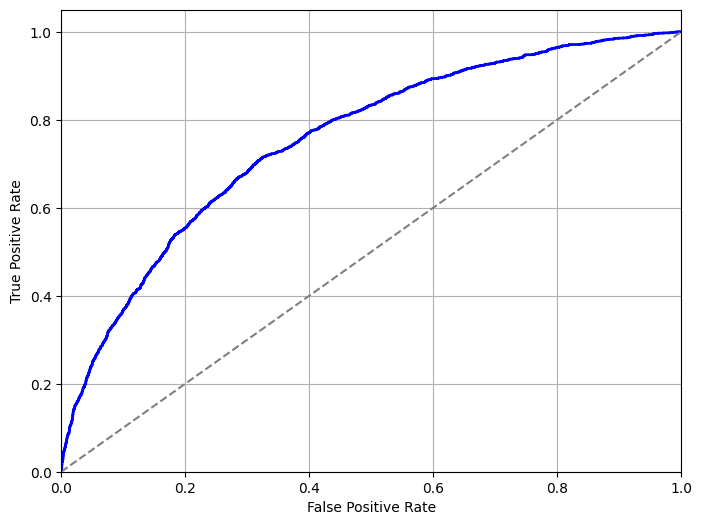

In [17]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

In [20]:
metrics.auc(fpr,tpr)

0.7537611088704603

# Logistic Regression Model

In [9]:
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [10]:
df_train = pd.get_dummies(df_train, columns=categorical_columns, drop_first=True)

In [11]:
X = df_train.drop('TARGET', axis = 1)
y = df_train['TARGET']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [14]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=100)

In [15]:
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [16]:
y_pred = model.predict(X_test)

C:\Users\bhyde\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4082857142857143
Confusion Matrix:
 [[6139 9903]
 [ 452 1006]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.38      0.54     16042
           1       0.09      0.69      0.16      1458

    accuracy                           0.41     17500
   macro avg       0.51      0.54      0.35     17500
weighted avg       0.86      0.41      0.51     17500



In [32]:
coefficients = model.coef_
avg_importance = np.mean(np.abs(coefficients), axis=0)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
#print(feature_importance)
uneeded = feature_importance[feature_importance['Importance'] <= 0.010126]
# Extract the list of features to drop
uneeded_features = uneeded['Feature'].tolist()

print(uneeded_features)

# Drop the unneeded columns from the dataframe
#X_dropped = X.drop(columns=uneeded_features)

['FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_10', 'CODE_GENDER_XNA', 'FLAG_MOBIL', 'FLAG_DOCUMENT_15', 'NAME_FAMILY_STATUS_Unknown', 'FLAG_DOCUMENT_19', 'ORGANIZATION_TYPE_Trade: type 1', 'ORGANIZATION_TYPE_Electricity', 'WALLSMATERIAL_MODE_Others', 'OCCUPATION_TYPE_IT staff', 'ENTRANCES_MODE', 'ORGANIZATION_TYPE_Industry: type 5', 'OCCUPATION_TYPE_Private service staff', 'AMT_INCOME_TOTAL', 'WALLSMATERIAL_MODE_Monolithic', 'OCCUPATION_TYPE_HR staff', 'ORGANIZATION_TYPE_Industry: type 13', 'OCCUPATION_TYPE_Laborers', 'FLAG_CONT_MOBILE', 'CNT_CHILDREN', 'WEEKDAY_APPR_PROCESS_START_WEDNESDAY', 'OCCUPATION_TYPE_Sales staff', 'NAME_TYPE_SUITE_Group of people', 'OCCUPATION_TYPE_Managers', 'NAME_TYPE_SUITE_Other_A', 'WEEKDAY_APPR_PROCESS_START_SATURDAY', 'OCCUPATION_TYPE_Waiters/barmen staff', 'WALLSMATERIAL_MODE_Wooden', 'OCCUPATION_TYPE_Secretaries', 'AMT_REQ_CREDIT_BUREAU_MON', 'FLAG_DOCUMENT_21', 'OCCUPATION_TYPE_Realty agents', 'ORGANIZATION_TYPE_Trade: type 6', 'WEEKDAY_APPR_PROCESS_START_TUESD

# Remove Uneeded columns and build better model

In [33]:
X = df_train.drop(columns=uneeded_features)
y = df_train['TARGET']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [36]:
model = LogisticRegression(solver='liblinear', C=0.01, penalty='l1', max_iter=1000)

In [37]:
model.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=1000, penalty='l1', solver='liblinear')

In [38]:
y_pred = model.predict(X_test)

C:\Users\bhyde\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9166857142857143
Confusion Matrix:
 [[16042     0]
 [ 1458     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     16042
           1       0.00      0.00      0.00      1458

    accuracy                           0.92     17500
   macro avg       0.46      0.50      0.48     17500
weighted avg       0.84      0.92      0.88     17500



C:\Users\bhyde\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bhyde\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bhyde\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [40]:
y_score = model.predict_proba(X_test)[:, 1]
print(y_score)

[0.00485849 0.00485849 0.00485849 ... 0.11302304 0.00485849 0.00485849]


C:\Users\bhyde\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [41]:
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

In [44]:
print(tpr)

[0. 1. 1.]


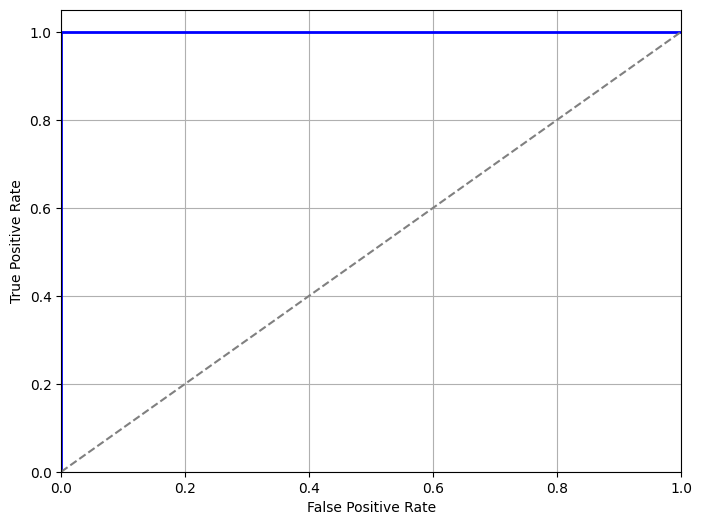

In [42]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()